In [3]:
# # --- Figure 3 notebook header ---
# import sys, pickle
# from pathlib import Path
# import pandas as pd, numpy as np, matplotlib.pyplot as plt

# here = Path.cwd()
# for p in [here, *here.parents]:
#     if (p / "utils.py").exists():
#         sys.path.insert(0, str(p)); REPO = p; break
# import utils
# utils.frontiers_style()

# cache = REPO / "cache"
# with open(cache / "meta.pkl", "rb") as f:
#     meta = pickle.load(f)
# file_names   = meta["file_names"]
# problem_type = meta["problem_type"]
# scores       = meta["scores"]
# with open(cache / "out_agg.pkl", "rb") as f:
#     out_agg = pickle.load(f)
# with open(cache / "ia_os_merge.pkl", "rb") as f:
#     ia_os = pickle.load(f)              

# basic_info = utils.load_basic_info()
# clf, reg = utils.split_problem_lists(file_names, basic_info)
# print(f"loaded: {len(file_names)} tasks | {len(clf)} clf | {len(reg)} reg | out_agg for {len(out_agg)} tasks")

loaded: 31 tasks | 14 clf | 17 reg | out_agg for 31 tasks


In [1]:
# ============================================================
# SUPPLEMENTARY ANALYSES (post-hoc, on processed frames)
# Builds from the committed raw metalearning data via utils (no pickles).
# Contains code + outputs for: statistical tests, MedAE metric-dependence,
# seed-sensitivity by algorithm, alternative-metric results, regression baselines.
# ============================================================

# --- header: build-from-source ---
import sys
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt
here = Path.cwd()
for p in [here, *here.parents]:
    if (p / "utils.py").exists():
        sys.path.insert(0, str(p)); REPO = p; break
import utils
utils.frontiers_style()

out = utils.process_all_tasks()
file_names = list(out['out_agg'].keys())
out_agg = out['out_agg']; ia_os = out['ia_os_merge']
basic_info = utils.load_basic_info()
clf, reg = utils.split_problem_lists(file_names, basic_info)
print(f"built: {len(file_names)} tasks | {len(clf)} clf | {len(reg)} reg")

--- ext_qual_binary
--- ext_qual_failure_mode
--- ext_qual_filament_outcome
--- ext_quant_avg_force
--- ext_quant_avg_force_under4
--- ext_quant_curves
--- ext_quant_max_force
--- ext_quant_max_force_under5
--- ext_quant_stability
--- ext_quant_std_force
--- microgel_formation
--- microgel_init_size
--- microgel_jamming_curves
--- microgel_jamming_curves_over08
--- microgel_shape
--- rheo_osc_strain_storage_curves
--- rheo_osc_stress_loss_curves
--- rheo_osc_stress_storage_curves
--- rheo_osc_yield_strain
--- rheo_osc_yield_strain_over10
--- rheo_osc_yield_stress
--- rheo_osc_yield_stress_over20
--- rheo_rot_shear_curves
--- rheo_rot_yield
built: 31 tasks | 14 clf | 17 reg


In [8]:
# Imports and helper functions 

import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import pandas as pd, numpy as np

def seed_range_by_algo(out_agg, tasks, metric):
    rows = []
    for t in tasks:
        df = out_agg[t]
        df = df[df['fold'] == 'test']
        # group over everything that defines a model EXCEPT the shuffle/seed,
        # then measure the spread of the metric across the 3 seeds, as % of the mean.
        grp_keys = ['algorithm', 'model_config_id', 'outer_k']   # adjust names to your columns
        g = df.groupby(grp_keys)['mean_' + metric]
        rng = (g.max() - g.min())
        mean = g.mean().abs()
        pct = 100.0 * rng / mean.replace(0, np.nan)              # % of mean; guard /0
        out = pct.reset_index(name='seed_range_pct')
        out['task'] = t
        rows.append(out)
    return pd.concat(rows, ignore_index=True).dropna(subset=['seed_range_pct'])


def winner_score(df, rank_col, score_col):
    """Per (iteration, outer_k), take the rank==1 winner's score; return median across those cells."""
    w = df[df[rank_col] == 1]
    per_cell = w.groupby(['iteration', 'outer_k'])[score_col].mean()
    return per_cell.median()


def collapse_per_task(task_list, ptype):
    m = METRIC[ptype]
    rows = {}
    for t in task_list:
        d_nest = ia_os[t]                                   # <-- NO fold filter (outer_ cols are the test scores)
        d_sing = out_agg[t]; d_sing = d_sing[d_sing['fold']=='test']   # out_agg DOES filter to test

        as_nest   = winner_score(d_nest, f'rank_as_mean_{m}',   f'outer_{m}')
        hpo_nest  = winner_score(d_nest, f'rank_hpo_mean_{m}',  f'outer_{m}')
        cash_nest = winner_score(d_nest, f'rank_cash_mean_{m}', f'outer_{m}')

        asw = d_nest[d_nest[f'rank_as_mean_{m}']==1]
        as_algo = asw['algorithm'].mode().iloc[0] if len(asw) else None
        ashpo_rows = d_nest[(d_nest['algorithm']==as_algo) & (d_nest[f'rank_hpo_mean_{m}']==1)]
        ashpo_nest = ashpo_rows.groupby(['iteration','outer_k'])[f'outer_{m}'].mean().median() \
                     if len(ashpo_rows) else np.nan

        as_single = winner_score(d_sing, f'rank_as_mean_{m}', f'mean_{m}')

        def as_at_k(df, k):
            w = df[(df[f'rank_as_mean_{m}']==1) & (df['outer_k']==k)]
            return w[f'outer_{m}'].mean() if len(w) else np.nan
        k2, k10 = as_at_k(d_nest, 2), as_at_k(d_nest, 10)

        rows[t] = dict(AS=as_nest, HPO=hpo_nest, CASH=cash_nest, ASHPO=ashpo_nest,
                       AS_single=as_single, AS_nested=as_nest, k2=k2, k10=k10)
    return pd.DataFrame(rows).T


def ptest(a, b, label):
    df = pd.DataFrame({'a':a,'b':b}).dropna()
    if len(df) < 5: return dict(comparison=label, n=len(df), stat=np.nan, p=np.nan, median_diff=np.nan)
    stat, p = wilcoxon(df['a'], df['b'], zero_method='wilcox')
    return dict(comparison=label, n=len(df), stat=stat, p=p, median_diff=float((df['a']-df['b']).median()))


In [6]:
Tc = collapse_per_task(clf, 'clf')
print(Tc.round(4).to_string())
print("\nNaN counts per column:")
print(Tc.isna().sum())

Tr = collapse_per_task(reg, 'reg')
print(Tr.round(4).to_string())
print("\nNaN counts:"); print(Tr.isna().sum())

                                       AS     HPO    CASH   ASHPO  AS_single  AS_nested      k2     k10
ext_qual_binary                    0.8637  0.8468  0.8569  0.8630     0.8694     0.8637  0.8661  0.8559
ext_qual_failure_mode              0.8098  0.7907  0.8173  0.8061     0.8394     0.8098  0.8048  0.8111
ext_qual_filament_outcome          0.8723  0.8468  0.8599  0.8689     0.8811     0.8723  0.8378  0.8834
ext_quant_avg_force_under4         0.8404  0.8294  0.8246  0.8312     0.8611     0.8404  0.8505  0.8472
ext_quant_max_force_under5         0.8357  0.8274  0.8193  0.8418     0.8611     0.8357  0.8365  0.8405
ext_quant_stability                0.8851  0.8779  0.8636  0.8886     0.8981     0.8851  0.8973  0.8821
microgel_formation                 0.8672  0.8716  0.8727  0.8765     0.8982     0.8672  0.8867  0.8985
microgel_jamming_curves_over08     0.7569  0.7239  0.7437  0.7597     0.7835     0.7569  0.6861  0.7576
microgel_shape                     0.7270  0.7542  0.7508  0.769

In [10]:
# ============================================================
# §S1 — Formal statistical tests (R2.5): Wilcoxon signed-rank, paired across tasks, BH-FDR
# Backs the manuscript's "systematic/measurable" claims. Task-level pairing (n=14 clf / 17 reg)
# avoids pseudo-replication.
# ============================================================
from statsmodels.stats.multitest import multipletests

METRIC = {'clf': 'accuracy', 'reg': 'MAE'}   # metric #1

Tc = collapse_per_task(clf, 'clf')   # existing helper (uses ia_os / out_agg)
Tr = collapse_per_task(reg, 'reg')

all_tests = []
for tag, T in [('clf', Tc), ('reg', Tr)]:
    all_tests += [
        ptest(T['HPO'],       T['AS'],        f'[{tag}] naive-HPO vs AS'),
        ptest(T['CASH'],      T['AS'],        f'[{tag}] CASH vs AS'),
        ptest(T['ASHPO'],     T['AS'],        f'[{tag}] AS→HPO vs AS'),
        ptest(T['AS_single'], T['AS_nested'], f'[{tag}] single vs nested'),
        ptest(T['k10'],       T['k2'],        f'[{tag}] k=10 vs k=2'),
    ]
stats_table = pd.DataFrame(all_tests)
stats_table['p_bh'] = multipletests(stats_table['p'], method='fdr_bh')[1]
stats_table['sig_bh'] = stats_table['p_bh'] < 0.05
stats_table = stats_table.round(5)
print(stats_table.to_string(index=False))

# save for the supplement (repo will contain the CSV + this notebook's rendered output)
stats_table.to_csv(REPO / "supplementary" / "S1_statistical_tests.csv", index=False)
print("\nsaved -> supplementary/S1_statistical_tests.csv")

            comparison  n  stat       p  median_diff    p_bh  sig_bh
 [clf] naive-HPO vs AS 14  13.0 0.01074     -0.01475 0.02686    True
      [clf] CASH vs AS 14  30.0 0.17261     -0.00959 0.24658   False
    [clf] AS→HPO vs AS 14  49.0 0.85522     -0.00170 0.92651   False
[clf] single vs nested 14   0.0 0.00012      0.02347 0.00122    True
     [clf] k=10 vs k=2 14  47.0 0.76086      0.00089 0.92651   False
 [reg] naive-HPO vs AS 17  12.0 0.00107     10.19082 0.00356    True
      [reg] CASH vs AS 17  74.0 0.92651     -0.07658 0.92651   False
    [reg] AS→HPO vs AS 17  40.0 0.08865     -0.92975 0.14776   False
[reg] single vs nested 17   0.0 0.00044     -0.74416 0.00219    True
     [reg] k=10 vs k=2 17  32.0 0.03479     -1.43207 0.06958   False

saved -> supplementary/S1_statistical_tests.csv


In [11]:
# ============================================================
# §S2 — Metric-dependence of selection (R2.7): re-run selection comparisons under MedAE
# Shows central findings are metric-robust (single-vs-nested, naive-HPO hold) while the
# finer strategy rankings (CASH, AS→HPO) are metric-DEPENDENT (significant under MedAE, not MAE).
# ============================================================
METRIC_medae = {'clf': 'accuracy', 'reg': 'MedAE'}   # swap the regression selection objective

# collapse regression tasks under MedAE-based selection (reuses winner_score internally)
def collapse_metric(task_list, ptype, metric_map):
    m = metric_map[ptype]
    rows = {}
    for t in task_list:
        d_nest = ia_os[t]
        d_sing = out_agg[t]; d_sing = d_sing[d_sing['fold']=='test']
        as_nest   = winner_score(d_nest, f'rank_as_mean_{m}',   f'outer_{m}')
        hpo_nest  = winner_score(d_nest, f'rank_hpo_mean_{m}',  f'outer_{m}')
        cash_nest = winner_score(d_nest, f'rank_cash_mean_{m}', f'outer_{m}')
        asw = d_nest[d_nest[f'rank_as_mean_{m}']==1]
        as_algo = asw['algorithm'].mode().iloc[0] if len(asw) else None
        ashpo_rows = d_nest[(d_nest['algorithm']==as_algo) & (d_nest[f'rank_hpo_mean_{m}']==1)]
        ashpo_nest = ashpo_rows.groupby(['iteration','outer_k'])[f'outer_{m}'].mean().median() if len(ashpo_rows) else np.nan
        as_single = winner_score(d_sing, f'rank_as_mean_{m}', f'mean_{m}')
        rows[t] = dict(AS=as_nest, HPO=hpo_nest, CASH=cash_nest, ASHPO=ashpo_nest,
                       AS_single=as_single, AS_nested=as_nest)
    return pd.DataFrame(rows).T

Tr_medae = collapse_metric(reg, 'reg', METRIC_medae)

medae_tests = [
    ptest(Tr_medae['AS_single'], Tr_medae['AS_nested'], '[reg/MedAE] single vs nested'),
    ptest(Tr_medae['HPO'],   Tr_medae['AS'], '[reg/MedAE] naive-HPO vs AS'),
    ptest(Tr_medae['CASH'],  Tr_medae['AS'], '[reg/MedAE] CASH vs AS'),
    ptest(Tr_medae['ASHPO'], Tr_medae['AS'], '[reg/MedAE] AS→HPO vs AS'),
]
medae_table = pd.DataFrame(medae_tests)
medae_table['p_bh'] = multipletests(medae_table['p'], method='fdr_bh')[1]
medae_table['sig_bh'] = medae_table['p_bh'] < 0.05
medae_table = medae_table.round(5)
print("MedAE-based selection (regression) — compare to MAE-based results in §S1:")
print(medae_table.to_string(index=False))

medae_table.to_csv(REPO / "supplementary" / "S2_medae_metric_dependence.csv", index=False)
print("\nsaved -> supplementary/S2_medae_metric_dependence.csv")

MedAE-based selection (regression) — compare to MAE-based results in §S1:
                  comparison  n  stat       p  median_diff    p_bh  sig_bh
[reg/MedAE] single vs nested 17   0.0 0.00002     -0.62239 0.00006    True
 [reg/MedAE] naive-HPO vs AS 17   8.0 0.00038      2.17295 0.00051    True
      [reg/MedAE] CASH vs AS 17  28.0 0.02016     -0.27720 0.02016    True
    [reg/MedAE] AS→HPO vs AS 17   4.0 0.00011     -0.16269 0.00021    True

saved -> supplementary/S2_medae_metric_dependence.csv


CLASSIFICATION seed-range % by algorithm:
           median    p95     max
algorithm                       
LR           8.76  34.88  119.10
KNN          1.10  13.86   31.13
SVM          0.00  11.38   73.28
RF           1.14   7.36   45.67
GB           0.00   4.73   27.11
MLP          0.00   1.94   40.12
GP           0.00   0.00   75.40

REGRESSION seed-range % by algorithm:
           median     p95     max
algorithm                        
LR           0.41  120.56  224.55
GP           0.00   31.85  162.40
KNN          0.42   23.55   43.52
MLP          0.00   10.04   55.56
RF           1.33    9.32   30.70
GB           0.14    5.34   27.53
SVM          0.00    0.00    3.48

saved S3 table CSVs + figure (pdf/png)


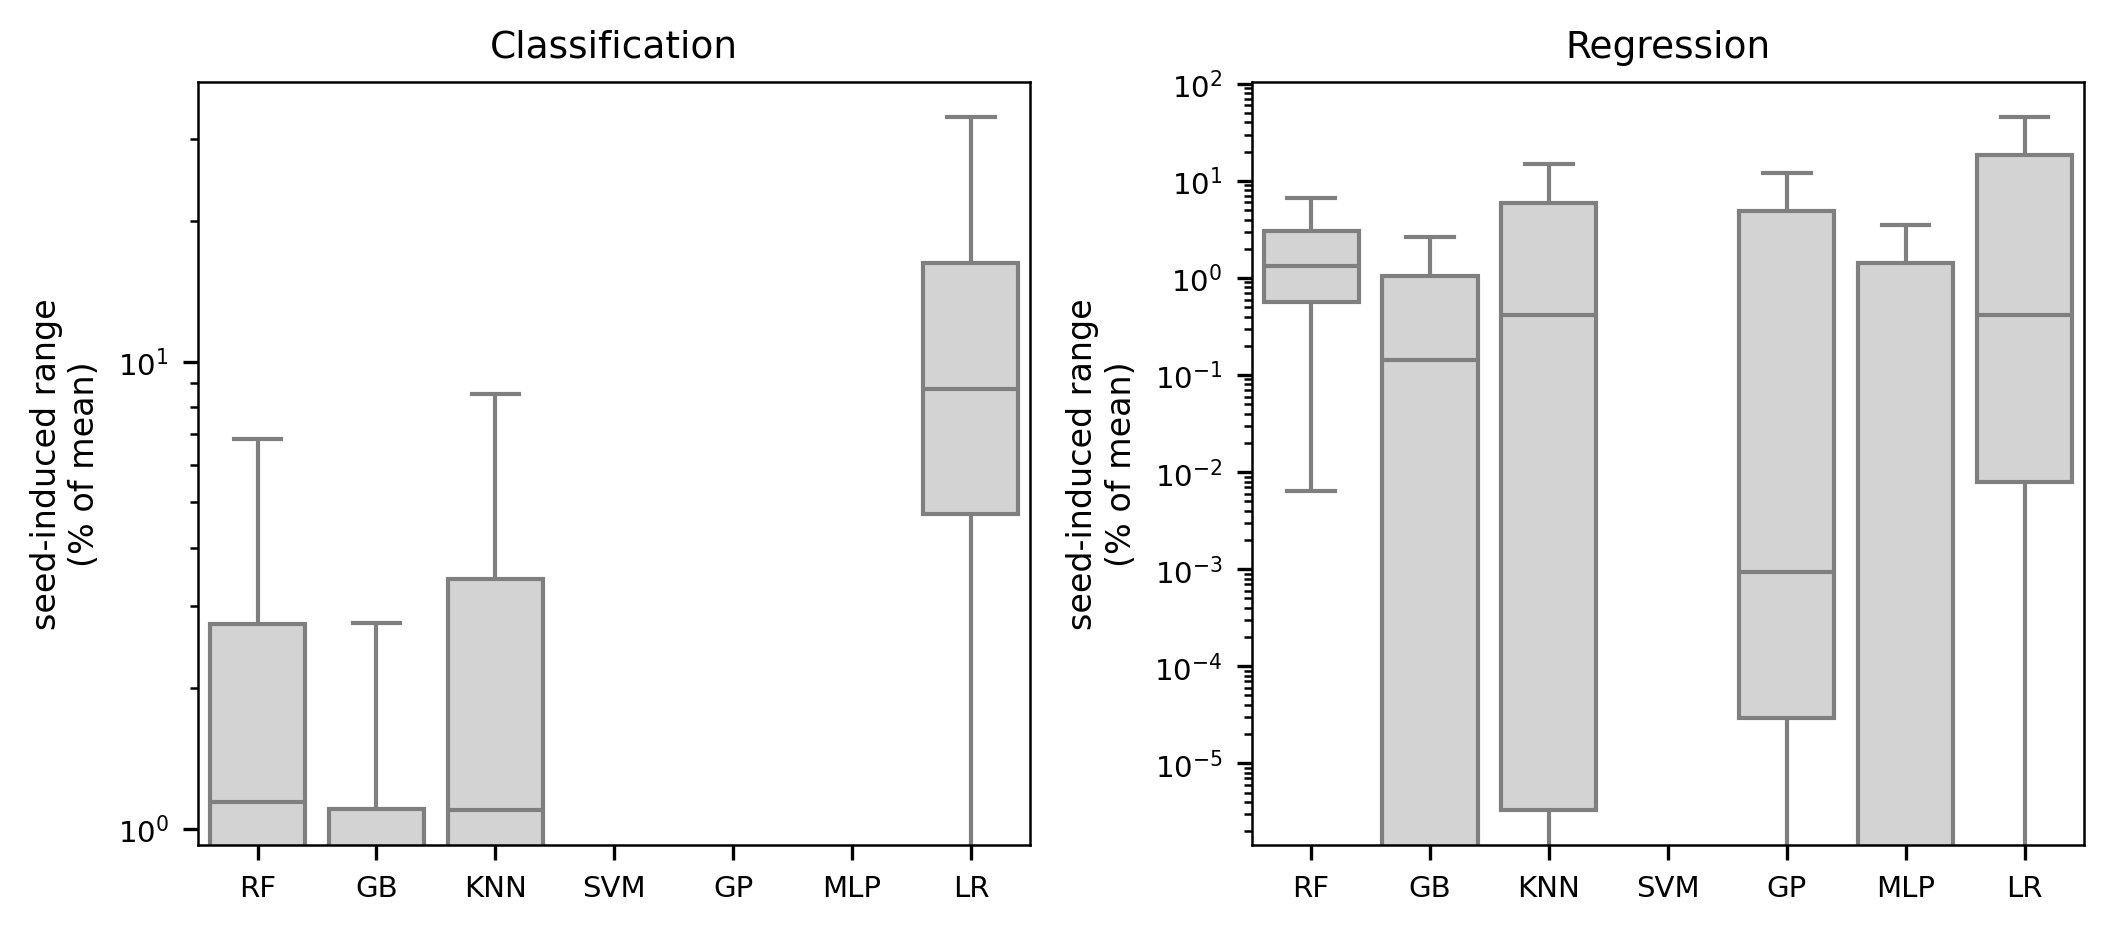

In [12]:
# ============================================================
# §S3 — Seed sensitivity by algorithm (R1.3): decompose the Fig 3 heavy tails
# Shows SGD-LR (and secondarily GP) drive the seed-sensitivity tails; tree ensembles are stable.
# ============================================================
import seaborn as sns

sr_clf = seed_range_by_algo(out_agg, clf, 'accuracy')   # your existing helper
sr_reg = seed_range_by_algo(out_agg, reg, 'MAE')

# summary tables
print("CLASSIFICATION seed-range % by algorithm:")
sc = sr_clf.groupby('algorithm')['seed_range_pct'].agg(median='median',
        p95=lambda x: np.percentile(x,95), max='max').round(2).sort_values('p95', ascending=False)
print(sc.to_string())
print("\nREGRESSION seed-range % by algorithm:")
sg = sr_reg.groupby('algorithm')['seed_range_pct'].agg(median='median',
        p95=lambda x: np.percentile(x,95), max='max').round(2).sort_values('p95', ascending=False)
print(sg.to_string())

# supplementary figure: per-algorithm distribution (log-y, heavy-tailed)
ALGO_ORDER = ['RF','GB','KNN','SVM','GP','MLP','LR']   # adjust to your label set if needed
fig, axes = plt.subplots(1, 2, figsize=(180/25.4, 80/25.4))
for ax, sr, title in [(axes[0], sr_clf, 'Classification'), (axes[1], sr_reg, 'Regression')]:
    order = [a for a in ALGO_ORDER if a in sr['algorithm'].unique()]
    sns.boxplot(data=sr, x='algorithm', y='seed_range_pct', order=order, ax=ax,
                showfliers=False, color='lightgray')
    ax.set_yscale('log'); ax.set_title(title)
    ax.set_ylabel('seed-induced range\n(% of mean)'); ax.set_xlabel('')
    ax.tick_params(axis='x', labelrotation=0)
plt.tight_layout()

# save table + figure
sc.to_csv(REPO / "supplementary" / "S3_seed_sensitivity_by_algo_clf.csv")
sg.to_csv(REPO / "supplementary" / "S3_seed_sensitivity_by_algo_reg.csv")
fig.savefig(REPO / "supplementary" / "S3_seed_sensitivity_by_algo.pdf", dpi=300, bbox_inches='tight')
fig.savefig(REPO / "supplementary" / "S3_seed_sensitivity_by_algo.png", dpi=300, bbox_inches='tight')
print("\nsaved S3 table CSVs + figure (pdf/png)")

In [13]:
# ============================================================
# §S4 — Metric-dependence of apparent difficulty (resolves "remaining metrics" +
#       "metric-dependence of apparent difficulty" references)
# Difficulty RANKING is mostly stable across clf metrics but imbalanced tasks swing hard:
# accuracy is inflated by imbalance; recall/f1 expose true difficulty.
# ============================================================
metrics_clf = ['accuracy', 'precision', 'recall', 'f1']

# per-task median of each metric (outer test), then rank (1 = hardest = lowest score)
rank_tbl = {}
for m in metrics_clf:
    d = pd.concat([out_agg[t] for t in clf], keys=clf, names=['task','row']).reset_index()
    d = d[d['fold']=='test']
    med_m = d.groupby('task', sort=False)['mean_'+m].median()
    rank_tbl[m] = med_m.rank(ascending=True)   # 1 = hardest

rank_df = pd.DataFrame(rank_tbl).astype(int)
rank_df['max_rank_shift'] = rank_df[metrics_clf].max(axis=1) - rank_df[metrics_clf].min(axis=1)
rank_df = rank_df.sort_values('max_rank_shift', ascending=False)
print("Classification difficulty RANK by metric (1 = hardest), sorted by rank instability:")
print(rank_df.to_string())

rank_df.to_csv(REPO / "supplementary" / "S4_difficulty_metric_dependence_clf.csv")
print("\nsaved -> supplementary/S4_difficulty_metric_dependence_clf.csv")

Classification difficulty RANK by metric (1 = hardest), sorted by rank instability:
                                   accuracy  precision  recall  f1  max_rank_shift
task                                                                              
rheo_osc_plateau_storage_over1000        13          9       3   3              10
ext_qual_binary                           9          7      13  11               6
rheo_osc_yield_strain_over10              5          6      10   9               5
rheo_osc_plateau_loss_under20            10          8       6   7               4
ext_quant_avg_force_under4                8         11       9  10               3
ext_quant_max_force_under5                7         10       8   8               3
ext_quant_stability                      11         14      12  13               3
microgel_size_evolution_under300         14         13      11  12               3
ext_qual_failure_mode                     3          2       4   4               2
mic

In [14]:
# ============================================================
# §S4 (cont.) — Compact per-task, per-metric summary tables (resolves "remaining metrics")
# Median held-out (outer test) value of every metric, per task. Shows the non-primary
# metrics without re-plotting (avoids the r2/MAPE plotting pathologies for regression).
# ============================================================

def per_task_metric_table(task_list, metric_list):
    rows = {}
    for t in task_list:
        d = out_agg[t]; d = d[d['fold']=='test']
        rows[t] = {m: d['mean_'+m].median() for m in metric_list}
    return pd.DataFrame(rows).T

clf_metrics = ['accuracy', 'precision', 'recall', 'f1']          # add 'balanced_accuracy','average_precision' if present
reg_metrics = ['MAE', 'MedAE', 'MAPE', 'r2']

# guard: only include metrics that actually exist as columns
def present(task, metrics):
    cols = out_agg[task].columns
    return [m for m in metrics if 'mean_'+m in cols]

clf_summary = per_task_metric_table(clf, present(clf[0], clf_metrics)).round(4)
reg_summary = per_task_metric_table(reg, present(reg[0], reg_metrics)).round(4)

print("CLASSIFICATION — median outer-test value per metric, per task:")
print(clf_summary.to_string())
print("\nREGRESSION — median outer-test value per metric, per task:")
print(reg_summary.to_string())

clf_summary.to_csv(REPO / "supplementary" / "S4_all_metrics_summary_clf.csv")
reg_summary.to_csv(REPO / "supplementary" / "S4_all_metrics_summary_reg.csv")
print("\nsaved -> S4_all_metrics_summary_clf.csv + S4_all_metrics_summary_reg.csv")

CLASSIFICATION — median outer-test value per metric, per task:
                                   accuracy  precision  recall      f1
ext_qual_binary                      0.8385     0.8456  0.9189  0.8767
ext_qual_failure_mode                0.7456     0.7334  0.7456  0.7281
ext_qual_filament_outcome            0.7567     0.7794  0.7567  0.7327
ext_quant_avg_force_under4           0.8241     0.8832  0.8605  0.8665
ext_quant_max_force_under5           0.8229     0.8741  0.8484  0.8510
ext_quant_stability                  0.8519     0.9263  0.9092  0.9079
microgel_formation                   0.8716     0.8990  0.9812  0.9306
microgel_jamming_curves_over08       0.7204     0.7450  0.7014  0.7071
microgel_shape                       0.7130     0.7035  0.7130  0.6772
microgel_size_evolution_under300     0.8997     0.9085  0.9035  0.8884
rheo_osc_plateau_loss_under20        0.8412     0.8518  0.8182  0.8076
rheo_osc_plateau_storage_over1000    0.8816     0.8611  0.7308  0.7254
rheo_osc_yield

In [15]:
# ============================================================
# §S5 — Regression trivial baselines (R2.6): mean- and median-prediction MAE per task
# = mean/median absolute deviation of each task's target. Computed from the base target
# data (which lives with the companion Paper 1 dataset, not duplicated here); values recorded
# below. The computation method is documented in Supplemental Notebook 1.
# ============================================================
reg_trivial_baselines = pd.DataFrame({
    'mean_pred_MAE': {
        'ext_quant_avg_force':2.2768,'ext_quant_curves':2.1492,'ext_quant_max_force':5.5316,
        'ext_quant_std_force':1.0950,'microgel_init_size':188.1601,'microgel_jamming_curves':0.1187,
        'microgel_size_evolution':197.7942,'rheo_osc_plateau_loss':269.8571,'rheo_osc_plateau_storage':1262.0053,
        'rheo_osc_strain_loss_curves':307.4445,'rheo_osc_strain_storage_curves':1393.3929,
        'rheo_osc_stress_loss_curves':307.4445,'rheo_osc_stress_storage_curves':1393.3929,
        'rheo_osc_yield_strain':10.0280,'rheo_osc_yield_stress':95.1471,'rheo_rot_shear_curves':1.9391,
        'rheo_rot_yield':123.8105,
    },
    'median_pred_MAE': {
        'ext_quant_avg_force':1.9631,'ext_quant_curves':1.9304,'ext_quant_max_force':4.2456,
        'ext_quant_std_force':0.7637,'microgel_init_size':185.5702,'microgel_jamming_curves':0.1139,
        'microgel_size_evolution':197.6824,'rheo_osc_plateau_loss':187.0014,'rheo_osc_plateau_storage':1004.4283,
        'rheo_osc_strain_loss_curves':220.4690,'rheo_osc_strain_storage_curves':1100.6971,
        'rheo_osc_stress_loss_curves':220.4690,'rheo_osc_stress_storage_curves':1100.6971,
        'rheo_osc_yield_strain':9.7254,'rheo_osc_yield_stress':76.4330,'rheo_rot_shear_curves':1.9322,
        'rheo_rot_yield':92.4561,
    },
})
# optionally: attach each task's actual model performance for context (median MAE from S4)
reg_trivial_baselines['best_model_median_MAE'] = reg_summary['MAE']
reg_trivial_baselines = reg_trivial_baselines.round(4)
print("Regression trivial baselines (mean- and median-prediction MAE) vs typical model MAE:")
print(reg_trivial_baselines.to_string())

reg_trivial_baselines.to_csv(REPO / "supplementary" / "S5_regression_trivial_baselines.csv")
print("\nsaved -> supplementary/S5_regression_trivial_baselines.csv")

Regression trivial baselines (mean- and median-prediction MAE) vs typical model MAE:
                                mean_pred_MAE  median_pred_MAE  best_model_median_MAE
ext_quant_avg_force                    2.2768           1.9631                 1.8253
ext_quant_curves                       2.1492           1.9304                 1.7326
ext_quant_max_force                    5.5316           4.2456                 4.3615
ext_quant_std_force                    1.0950           0.7637                 0.8870
microgel_init_size                   188.1601         185.5702                57.5094
microgel_jamming_curves                0.1187           0.1139                 0.0994
microgel_size_evolution              197.7942         197.6824                69.2724
rheo_osc_plateau_loss                269.8571         187.0014               143.4967
rheo_osc_plateau_storage            1262.0053        1004.4283               794.2258
rheo_osc_strain_loss_curves          307.4445         2